# Job Recommendation

<img src='https://miro.medium.com/0*0g5OCj_BelSntR1y.png'>

Bu çalışmada iş ilanları üzerinden en popüler meslekler tespit edilerek meslek öneri mekanizması geliştirilecektir.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import nltk
import re
from nltk.corpus import stopwords
import string

In [2]:
df = pd.read_csv("marketing_sample_for_naukri_com-jobs__20190701_20190830__30k_data.csv")

In [3]:
df.head()

,Uniq Id,Crawl Timestamp,Job Title,Job Salary,Job Experience Required,Key Skills,Role Category,Location,Functional Area,Industry,Role
0,9be62c49a0b7ebe982a4af1edaa7bc5f,2019-07-05 01:46:07 +0000,Digital Media Planner,Not Disclosed by Recruiter,5 - 10 yrs,Media Planning| Digital Media,Advertising,Mumbai,"Marketing , Advertising , MR , PR , Media Plan...","Advertising, PR, MR, Event Management",Media Planning Executive/Manager
1,3c52d436e39f596b22519da2612f6a56,2019-07-06 08:04:50 +0000,Online Bidding Executive,Not Disclosed by Recruiter,2 - 5 yrs,pre sales| closing| software knowledge| clien...,Retail Sales,"Pune,Pune","Sales , Retail , Business Development","IT-Software, Software Services",Sales Executive/Officer
2,ffad8a2396c60be2bf6d0e2ff47c58d4,2019-08-05 15:50:44 +0000,Trainee Research/ Research Executive- Hi- Tec...,Not Disclosed by Recruiter,0 - 1 yrs,Computer science| Fabrication| Quality check|...,R&D,Gurgaon,"Engineering Design , R&D","Recruitment, Staffing",R&D Executive
3,7b921f51b5c2fb862b4a5f7a54c37f75,2019-08-05 15:31:56 +0000,Technical Support,"2,00,000 - 4,00,000 PA.",0 - 5 yrs,Technical Support,Admin/Maintenance/Security/Datawarehousing,Mumbai,"IT Software - Application Programming , Mainte...","IT-Software, Software Services",Technical Support Engineer
4,2d8b7d44e138a54d5dc841163138de50,2019-07-05 02:48:29 +0000,Software Test Engineer -hyderabad,Not Disclosed by Recruiter,2 - 5 yrs,manual testing| test engineering| test cases|...,Programming & Design,Hyderabad,IT Software - QA & Testing,"IT-Software, Software Services",Testing Engineer


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Uniq Id                  30000 non-null  object
 1   Crawl Timestamp          30000 non-null  object
 2   Job Title                29425 non-null  object
 3   Job Salary               29950 non-null  object
 4   Job Experience Required  29427 non-null  object
 5   Key Skills               28729 non-null  object
 6   Role Category            27695 non-null  object
 7   Location                 29423 non-null  object
 8   Functional Area          29427 non-null  object
 9   Industry                 29427 non-null  object
 10  Role                     29099 non-null  object
dtypes: object(11)
memory usage: 2.5+ MB


In [5]:
df.isnull().sum()

Uniq Id                       0
Crawl Timestamp               0
Job Title                   575
Job Salary                   50
Job Experience Required     573
Key Skills                 1271
Role Category              2305
Location                    577
Functional Area             573
Industry                    573
Role                        901
dtype: int64

In [6]:
df.shape

(30000, 11)

In [7]:
# Eksik değerleri silelim
df = df.dropna(axis=1, how='all')

In [8]:
df.head()

,Uniq Id,Crawl Timestamp,Job Title,Job Salary,Job Experience Required,Key Skills,Role Category,Location,Functional Area,Industry,Role
0,9be62c49a0b7ebe982a4af1edaa7bc5f,2019-07-05 01:46:07 +0000,Digital Media Planner,Not Disclosed by Recruiter,5 - 10 yrs,Media Planning| Digital Media,Advertising,Mumbai,"Marketing , Advertising , MR , PR , Media Plan...","Advertising, PR, MR, Event Management",Media Planning Executive/Manager
1,3c52d436e39f596b22519da2612f6a56,2019-07-06 08:04:50 +0000,Online Bidding Executive,Not Disclosed by Recruiter,2 - 5 yrs,pre sales| closing| software knowledge| clien...,Retail Sales,"Pune,Pune","Sales , Retail , Business Development","IT-Software, Software Services",Sales Executive/Officer
2,ffad8a2396c60be2bf6d0e2ff47c58d4,2019-08-05 15:50:44 +0000,Trainee Research/ Research Executive- Hi- Tec...,Not Disclosed by Recruiter,0 - 1 yrs,Computer science| Fabrication| Quality check|...,R&D,Gurgaon,"Engineering Design , R&D","Recruitment, Staffing",R&D Executive
3,7b921f51b5c2fb862b4a5f7a54c37f75,2019-08-05 15:31:56 +0000,Technical Support,"2,00,000 - 4,00,000 PA.",0 - 5 yrs,Technical Support,Admin/Maintenance/Security/Datawarehousing,Mumbai,"IT Software - Application Programming , Mainte...","IT-Software, Software Services",Technical Support Engineer
4,2d8b7d44e138a54d5dc841163138de50,2019-07-05 02:48:29 +0000,Software Test Engineer -hyderabad,Not Disclosed by Recruiter,2 - 5 yrs,manual testing| test engineering| test cases|...,Programming & Design,Hyderabad,IT Software - QA & Testing,"IT-Software, Software Services",Testing Engineer


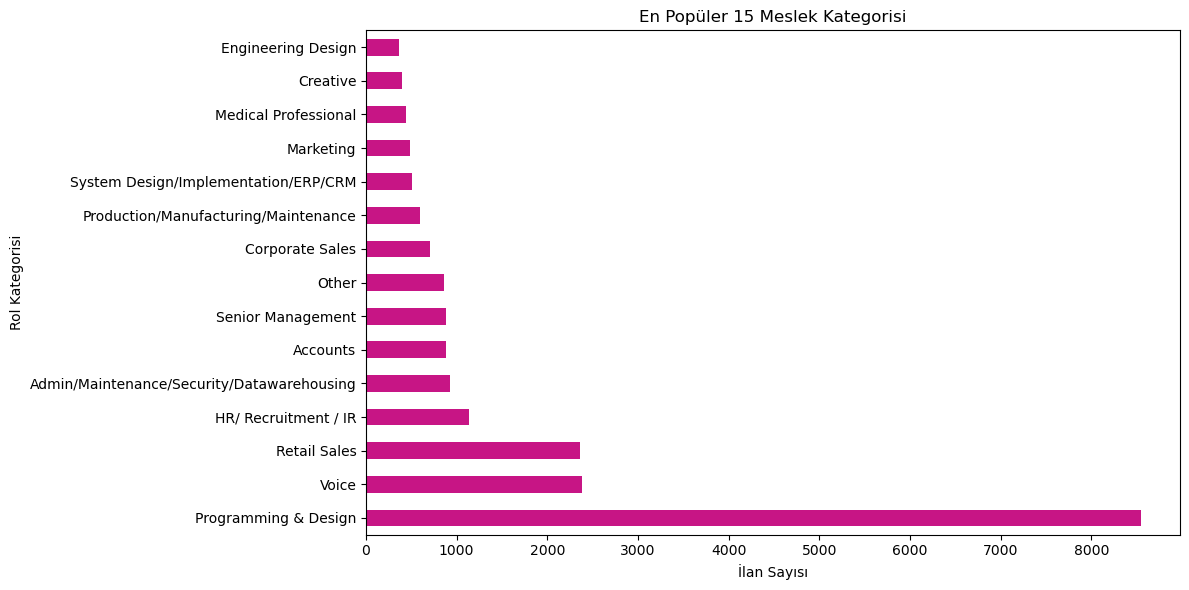

In [41]:
# Role Category dağılımı
plt.figure(figsize=(12, 6))
df['Role Category'].value_counts().head(15).plot(kind='barh', color='#C71585')
plt.xlabel('İlan Sayısı')
plt.ylabel('Rol Kategorisi')
plt.title('En Popüler 15 Meslek Kategorisi')
plt.tight_layout()
plt.show()

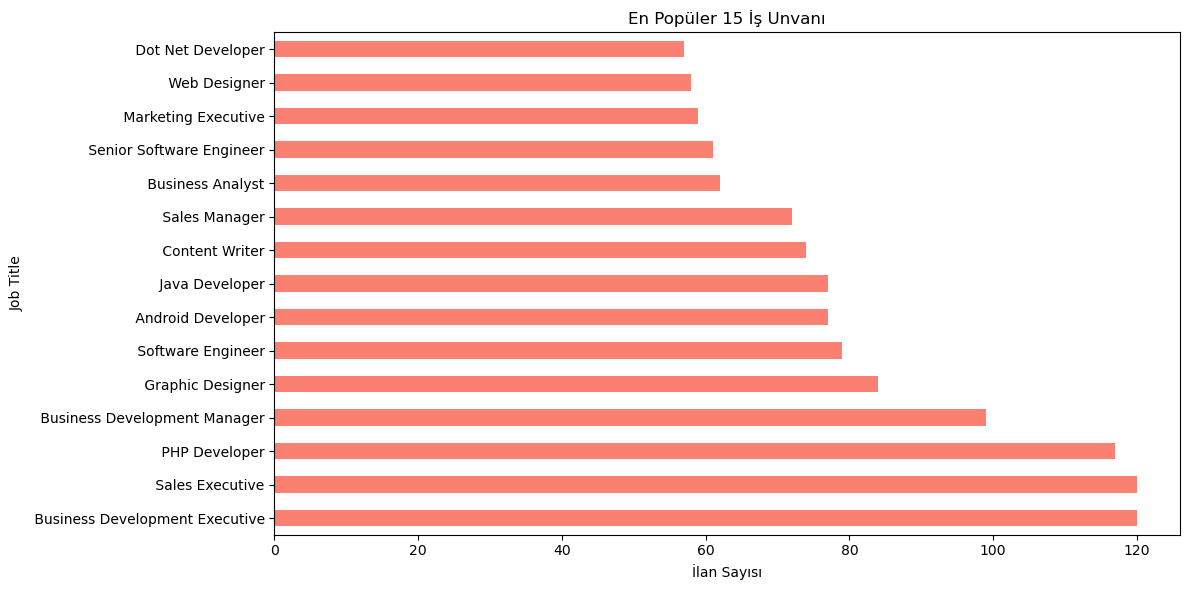

In [42]:
# Job Title dağılımı
plt.figure(figsize=(12, 6))
df['Job Title'].value_counts().head(15).plot(kind='barh', color='#FA8072')
plt.xlabel('İlan Sayısı')
plt.ylabel('Job Title')
plt.title('En Popüler 15 İş Unvanı')
plt.tight_layout()
plt.show()

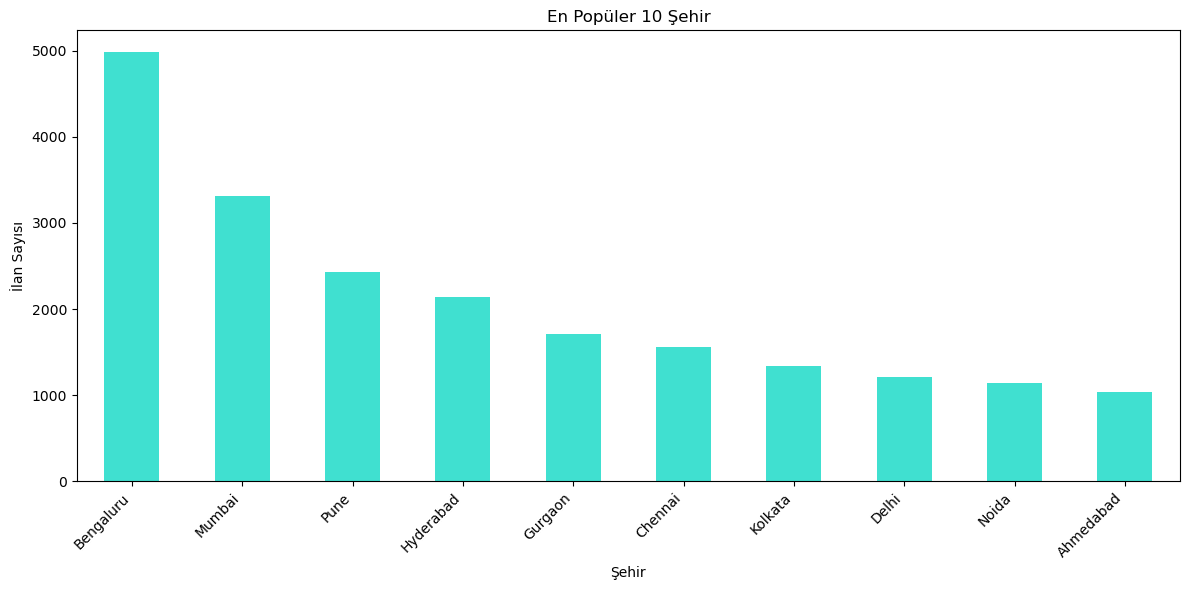

In [11]:
# Top 10 Location
plt.figure(figsize=(12, 6))
df['Location'].value_counts().head(10).plot(kind='bar', color='#40E0D0')
plt.xlabel('Şehir')
plt.ylabel('İlan Sayısı')
plt.title('En Popüler 10 Şehir')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
#Hangi mesleklerin kaç ilan olduğunu bilmek için aynı mesleği bir araya toplayıp sayıyoruz, bunun için groupby yaptık

In [12]:
#Role Kategoriye göre gruplandıralım 
ilan_sayisi = df.groupby('Role Category')['Uniq Id'].count()
meslek_istatistik = ilan_sayisi.reset_index(name='ilan_sayisi')

In [13]:
# Populer meslekleri sıralayaım, burada en çok talep gören işi en üste getirerek en popüler meslekleri göreceğiz.
populer_meslekler = meslek_istatistik.sort_values(by='ilan_sayisi', ascending=False)

In [14]:
populer_meslekler

,Role Category,ilan_sayisi
156,Programming & Design,8551
196,Voice,2385
165,Retail Sales,2359
107,HR/ Recruitment / IR,1133
42,Admin/Maintenance/Security/Datawarehousing,928
...,...,...
201,We Have urgent requirement for OKTA Experienc...,1
202,Xoriant Corporation is a product engineering a...,1
203,axaxl.com,1
204,https://www.artechinfo.in/,1


In [15]:
# İlan sayılarını yüzdelik orana çevirelim
toplam_ilan = populer_meslekler['ilan_sayisi'].sum()
populer_meslekler['yuzde'] = (populer_meslekler['ilan_sayisi'] / toplam_ilan) * 100

In [16]:
# Ranking En iyi tavsiye hangisi diye kolayca görmek için;
populer_meslekler['siralama'] = populer_meslekler['yuzde'].rank(ascending=False)

In [17]:
#Job Tavsiyesi olarak;

In [18]:
populer_meslekler.sort_values(by='siralama', ascending=True).head(15)

,Role Category,ilan_sayisi,yuzde,siralama
156,Programming & Design,8551,30.875609,1.0
196,Voice,2385,8.611663,2.0
165,Retail Sales,2359,8.517783,3.0
107,HR/ Recruitment / IR,1133,4.090991,4.0
42,Admin/Maintenance/Security/Datawarehousing,928,3.350785,5.0
41,Accounts,882,3.184690,6.0
173,Senior Management,880,3.177469,7.0
148,Other,865,3.123307,8.0
75,Corporate Sales,704,2.541975,9.0
153,Production/Manufacturing/Maintenance,592,2.137570,10.0


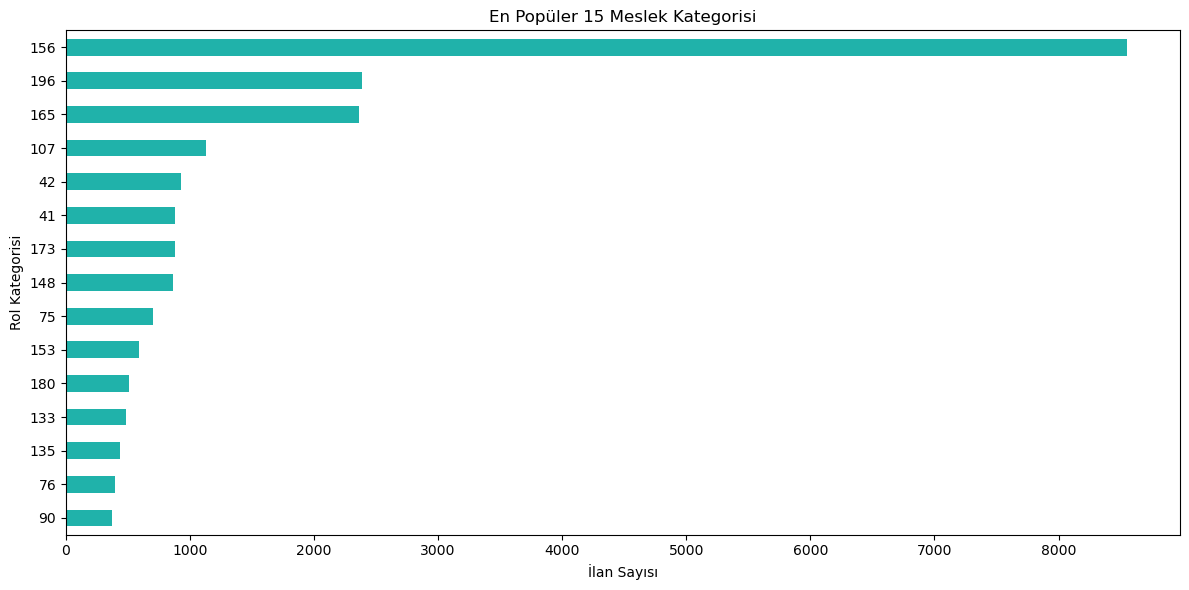

In [19]:
#En Polüler Meslekler
plt.figure(figsize=(12, 6))
populer_meslekler.head(15).sort_values(by='ilan_sayisi', ascending=True)['ilan_sayisi'].plot(kind='barh', color='#20B2AA')
plt.xlabel('İlan Sayısı')
plt.ylabel('Rol Kategorisi')
plt.title('En Popüler 15 Meslek Kategorisi')
plt.tight_layout()
plt.show()

In [28]:
from collections import Counter
from wordcloud import WordCloud
from wordcloud import STOPWORDS
from PIL import Image

In [22]:
# Tüm skills'i bir liste halinde topla
tum_skills = ' '.join(df['Key Skills'].astype(str))

# Boşluklara göre ayır
skills_list = tum_skills.split('|')

# Temizle (başı ve sonundaki boşlukları kaldır)
skills_list = [skill.strip() for skill in skills_list]

In [23]:
# En sık kullanılan 20 skill'i bul
en_sık_skills = Counter(skills_list).most_common(20)

skills_df = pd.DataFrame(en_sık_skills, columns=['Skill', 'Frekans'])

skills_df

,Skill,Frekans
0,Manager,2713
1,Developer,2420
2,Sales,2151
3,Executive,1471
4,Javascript,1183
5,Engineer,1119
6,HTML,1069
7,Software,1053
8,HR,1004
9,Java,747


In [24]:
# 2li kelimeleri bul (bigrams)
bigrams = []

for skill in skills_list:
    words = skill.split()
    for i in range(len(words) - 1):
        bigram = words[i] + ' ' + words[i + 1]
        bigrams.append(bigram)

In [38]:
# En sık kullanılan 2li kelimeleri bul
en_sık_bigrams = Counter(bigrams).most_common(50)

bigrams_df = pd.DataFrame(en_sık_bigrams, columns=['2li Kelime', 'Frekans'])

bigrams_df

,2li Kelime,Frekans
0,Business Development,1005
1,Business Executive,807
2,business development,749
3,Technical support,656
4,Customer Service,649
5,voice process,645
6,customer service,596
7,Computer science,591
8,MS Office,538
9,sales executive,523


In [26]:
# 3lü kelimeleri bul (trigrams)
trigrams = []

for skill in skills_list:
    words = skill.split()
    for i in range(len(words) - 2):
        trigram = words[i] + ' ' + words[i + 1] + ' ' + words[i + 2]
        trigrams.append(trigram)

In [35]:
# En sık kullanılan 3lü kelimeleri bul
en_sık_trigrams = Counter(trigrams).most_common(50)

trigrams_df = pd.DataFrame(en_sık_trigrams, columns=['3lü Kelime', 'Frekans'])

trigrams_df

,3lü Kelime,Frekans
0,international call center,153
1,Business Development Executive,147
2,customer care executive,141
3,Sales Executive Activities,131
4,Customer Care Executive,112
5,business development executive,97
6,development life cycle,87
7,international voice process,87
8,Business Development Manager,82
9,International Call Center,79


In [36]:
def wc(data, color):
    plt.figure(figsize=(10, 10))
    mask=np.array(Image.open('cloud.png'))
    wc = WordCloud(background_color=color, stopwords=STOPWORDS, mask=mask)  
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis('off')  
    plt.show() 

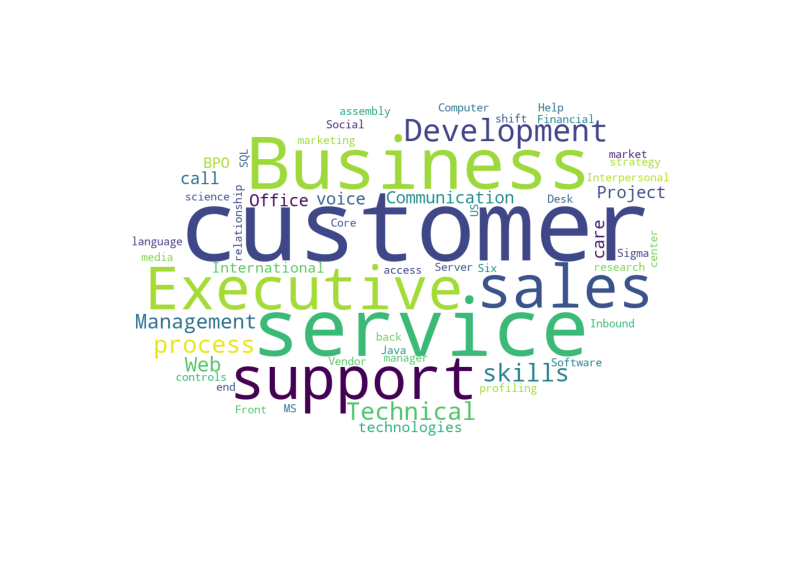

In [39]:
wc(bigrams_df['2li Kelime'],'white')

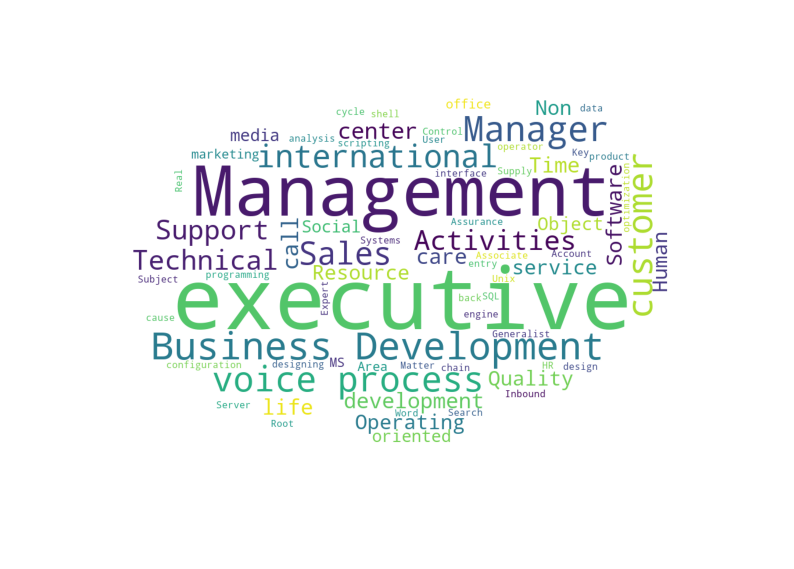

In [37]:
wc(trigrams_df['3lü Kelime'],'white')

Bu çalışmada iş ilanlarına göre en popüler meslek gruplarını tespit ederek meslek önerisinde bulunulmuştur. Bu kapsamda; en popüler meslekler sırasıyla; Programming & Design, Voice ve Retail Sales şeklindedir. Ek olarak data setinde en çok geçen 2'li ve 3'lü kelime grupları sıralanmıştır. 